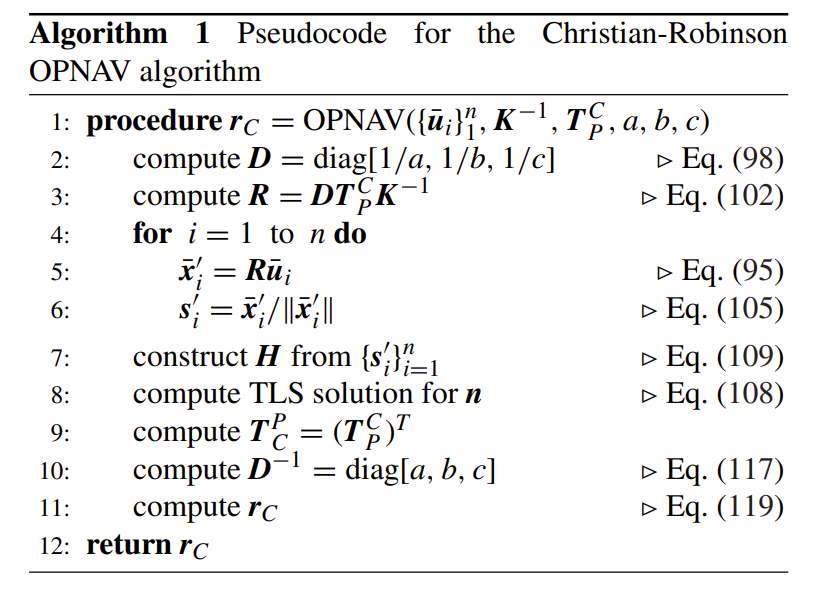

# The Christian Robinson method for horizon edge detection:

- D ... ie a,b,c

- assuming sphere so a=b=c 
$$X^2/a^2 + Y^2/b^2 + Z^2/c^2 = 1$$


- ${ui}_1^n$ edge points we generate these
- $K^-1$

Camera calibration matrix inverse:

$$K^{-1} = \begin{bmatrix} 1/d_x & -\alpha/(d_x d_y) & \alpha v_p - d_y u_p \\ 0 & 1/d_y & -v_p/d_y \\ 0 & 0 & 1 \end{bmatrix}$$


- $d_y= f/\mu_y$ where $f$ is the focal length and $\mu_y$ is the distance from pixel center to pixel center in y direction
- $d_x = f/\mu_x$ where $\mu_x$ is the distance from pixel center to pixel center in x direction 


- maybe just pull and example from online




- $T_p^C$ relative attitude between the celestial body’s frame and the camera frame 

$$T_C^ST_S^I(T_P^I)^T=T_C^ST_S^IT_I^P$$

Where:
- $T_P^I$ : celestial body's inertial attitude -> publically availbale from SPICE
- $T_S^I$ : spacecraft inertial attitude -> we petend a startracker is giving us perfect attitude knowledge, so we generate this as identity this will be spacecraft frame. 
- $T_C^S$ : camera attitude relative to spacecraft/startracker -> we generate

-  $r_C$ relative position expressed in the camera frame
- $r_p$ relative position expressed in the celestial body frame


We want r_p 


Now to simiplify this as much as possible,

The Ts are rotation matrics, no rotation between the camera and startracker, so $T_S^S$ is identity
$$T_S^S = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$$

A rotation of 180 degrees between the startracker and the camera, so $T_C^S$ is a 180 degree rotation about the y axis

$$T_C^S = \begin{bmatrix} -1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & -1 \end{bmatrix}$$




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

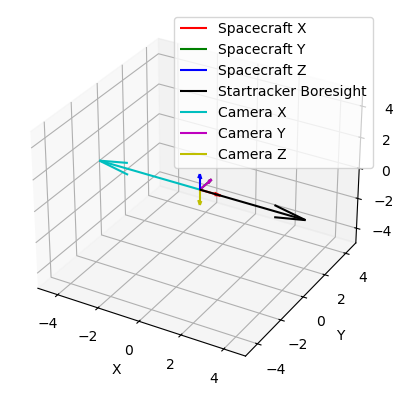

In [11]:
# plotting camera reference frame and startracker reference frame in the same plot, with a 90 degree rotation between them, and the startracker pointed opposite the body, so the camera is pointed at the body. The camera is at (300, 0, 4_000_000) in world coordinates, and the startracker is at (0, 0, 4_000_000) in world coordinates. The camera has a horizontal field of view of 20 degrees, and the image is 1280x720 pixels. The camera intrinsics are K = [[fx, 0, cx], [0, fy, cy], [0, 0, 1]] where fx = fy = 1000 and cx = width/2 and cy = height/2. The celestial body is a sphere with radius 1_000_000 meters.

T_C_S = np.array([[-1, 0, 0], [0, 1, 0], [0, 0, -1]])  # Camera is rotated 90 degrees about the y-axis from the startracker
T_S_S = np.eye(3)  # Startracker is aligned with the spacecraft body frame

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# scale x component/borsight vector by 5 to make it more visible in the plot

# Plot Spacecraft reference frame
ax.quiver(0, 0, 0, 1, 0, 0, color='r', label='Spacecraft X')
ax.quiver(0, 0, 0, 0, 1, 0, color='g', label='Spacecraft Y')
ax.quiver(0, 0, 0, 0, 0, 1, color='b', label='Spacecraft Z')

#plot startracker boresight vector
ax.quiver(0, 0, 0, 5*T_S_S[0, 0], T_S_S[1, 0], T_S_S[2, 0], color='k', label='Startracker Boresight')

# Plot camera reference frame   
ax.quiver(0, 0, 0, 5*T_C_S[0, 0], T_C_S[1, 0], T_C_S[2, 0], color='c', label='Camera X')
ax.quiver(0, 0, 0, T_C_S[0, 1], T_C_S[1, 1], T_C_S[2, 1], color='m', label='Camera Y')
ax.quiver(0, 0, 0, T_C_S [0, 2], T_C_S[1, 2], T_C_S[2, 2], color='y', label='Camera Z')
ax.set_xlim(-5, 5 )
ax.set_ylim(-5, 5)
ax.set_zlim(-5, 5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

So the process is: 
1) we have a trajectory ie a set of positions [x, y, z, vx, vy, vz] for the spacecraft and a time vector.
2) for now we can assume we are looking at the center of the body. 
3) We can find the bodies relative inertial attitude $T_P^I$ from SPICE
4) And then we can find the cameras 


or 

I just make up T^c_P and r_p and then generate the image from that, and then see if I can get back to the same T^c_P and r_p from the image.